# Analisi di `transactions_simple_delta_train.csv`

Dataset sintetico generato dall'esperimento **`simple_delta`**: i clienti
appartengono a quattro cluster (`veloce`, `medio`, `lento`, `lentissimo`)
che condividono **lo stesso profilo di spesa e le stesse variabili
categoriche**. L'unico segnale discriminante introdotto dal generatore è il
**gap temporale** tra transazioni consecutive (`delta_t`).

Obiettivi del notebook:
1. verificare che `importo`, `merchant` e `cocau` siano sostanzialmente
   sovrapposti tra cluster;
2. misurare come i cluster si separano solo sulle statistiche temporali;
3. costruire feature aggregate **per cliente** e proiettarle in 2D con
   **PCA** e **t-SNE**.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True
pd.set_option('display.max_columns', 60)


mkdir -p failed for path /home/vscode/.config/matplotlib: [Errno 13] Permission denied: '/home/vscode/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-t04o01ix because there was an issue with the default path (/home/vscode/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
def find_repo_root(start: Path) -> Path:
    """Risale le cartelle finché trova la radice del repo (data/ + config.toml)."""
    for p in [start, *start.parents]:
        if (p / 'data').is_dir() and (p / 'config.toml').exists():
            return p
    return start


ROOT = find_repo_root(Path.cwd())
CSV = ROOT / 'data' / 'transactions_simple_delta_pred.csv'

CLIENT, CLUSTER, TS = 'client_id', 'cluster', 'timestamp'
AMOUNT, MERCHANT, COCAU = 'importo', 'merchant', 'cocau'

df = pd.read_csv(CSV)
df[TS] = pd.to_datetime(df[TS], unit='s')
df = df.sort_values([CLIENT, TS]).reset_index(drop=True)
df['delta_t_days'] = df.groupby(CLIENT)[TS].diff().dt.total_seconds() / 86400.0

clusters = ['veloce', 'medio', 'lento', 'lentissimo']
colors_map = {
    'veloce': 'tab:green',
    'medio': 'tab:blue',
    'lento': 'tab:orange',
    'lentissimo': 'tab:red',
}
theoretical_mean_gap_days = {
    'veloce': 2.0,
    'medio': 1.0 / 0.1429,
    'lento': 20.0,
    'lentissimo': 50.0,
}

print('File:', CSV)
print('Righe x colonne:', df.shape)
df.head()


File: /workspaces/be-bper-ai-toolchain-bseq-app/data/transactions_simple_delta_pred.csv
Righe x colonne: (608571, 7)


,client_id,cluster,timestamp,importo,merchant,cocau,delta_t_days
0,0,lento,2023-09-08 01:21:20,55.374131,Aldi,149,NaN
1,0,lento,2023-10-09 00:36:37,197.166348,Trenitalia,33,30.968947
2,0,lento,2023-10-10 01:04:05,155.404987,Booking,185,1.019074
3,0,lento,2023-10-15 03:27:33,37.054429,Walmart,120,5.099630
4,0,lento,2023-10-15 05:24:55,-3.454091,Aldi,8,0.081505


## 0. Panoramica e qualità dei dati


In [3]:
overview = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'n_unique': df.nunique(dropna=True),
})
display(overview)

df.describe(include='all').transpose().head(10)


,dtype,missing,n_unique
client_id,int64,0,4000
cluster,object,0,4
timestamp,datetime64[ns],0,608099
importo,float64,0,608571
merchant,object,0,26
cocau,int64,0,26
delta_t_days,float64,4000,515847


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
client_id,608571.0,NaN,NaN,NaN,2014.972963,0.0,1019.0,2029.0,3010.0,3999.0,1153.141409
cluster,608571,4,lento,154958,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timestamp,608571,NaN,NaN,NaN,2026-12-17 08:40:44.509270016,2020-01-01 12:11:57,2022-09-10 09:49:44.500000,2024-05-14 14:35:32,2028-09-17 08:24:23,2078-08-31 03:46:19,NaN
importo,608571.0,NaN,NaN,NaN,80.579303,-83.459295,40.519912,70.409846,110.831822,341.713868,56.095017
merchant,608571,26,RyanAir,23785,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cocau,608571.0,NaN,NaN,NaN,114.397903,8.0,101.0,120.0,120.0,296.0,50.847552
delta_t_days,604571.0,NaN,NaN,NaN,19.922036,0.0,1.978264,6.879132,22.857986,645.450278,33.062926


## 1. Bilanciamento dei cluster

Numero di clienti e di transazioni per cluster (verità di riferimento).


,n_clients,n_transactions,tx_per_client
cluster,,,
veloce,1000,150914,150.9
medio,1000,149524,149.5
lento,1000,154958,155.0
lentissimo,1000,153175,153.2


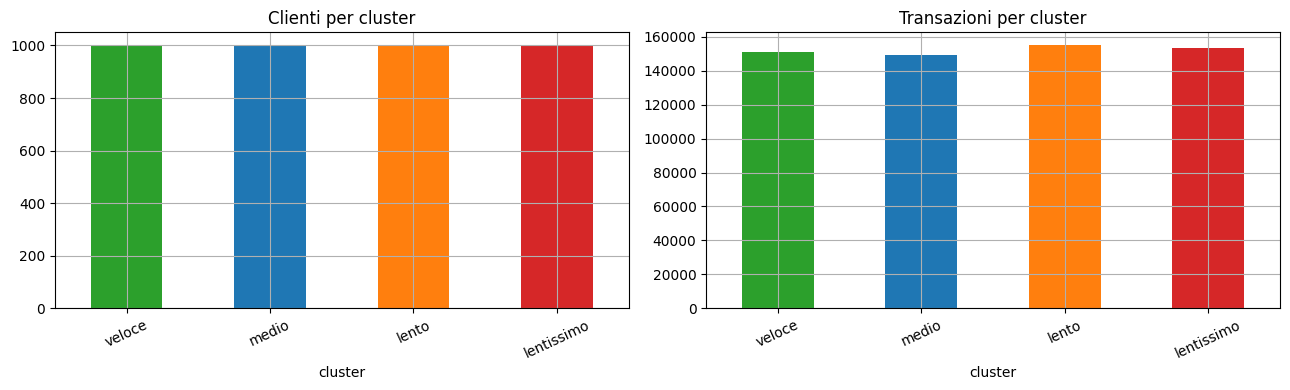

In [4]:
n_clients = df.groupby(CLUSTER)[CLIENT].nunique().reindex(clusters)
n_tx = df[CLUSTER].value_counts().reindex(clusters)
summary = pd.DataFrame({'n_clients': n_clients, 'n_transactions': n_tx})
summary['tx_per_client'] = (summary['n_transactions'] / summary['n_clients']).round(1)
display(summary)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
n_clients.plot.bar(ax=ax[0], color=[colors_map[c] for c in clusters], title='Clienti per cluster')
n_tx.plot.bar(ax=ax[1], color=[colors_map[c] for c in clusters], title='Transazioni per cluster')
for a in ax:
    a.tick_params(axis='x', rotation=25)
plt.tight_layout()


## 2. Distribuzione di `importo`

In `simple_delta` **non** ci aspettiamo una separazione forte: tutti i
cluster condividono lo stesso profilo di spesa.


,mean,median,std
cluster,,,
veloce,80.64,70.40,56.05
medio,80.62,70.55,56.06
lento,80.56,70.42,56.04
lentissimo,80.49,70.29,56.23


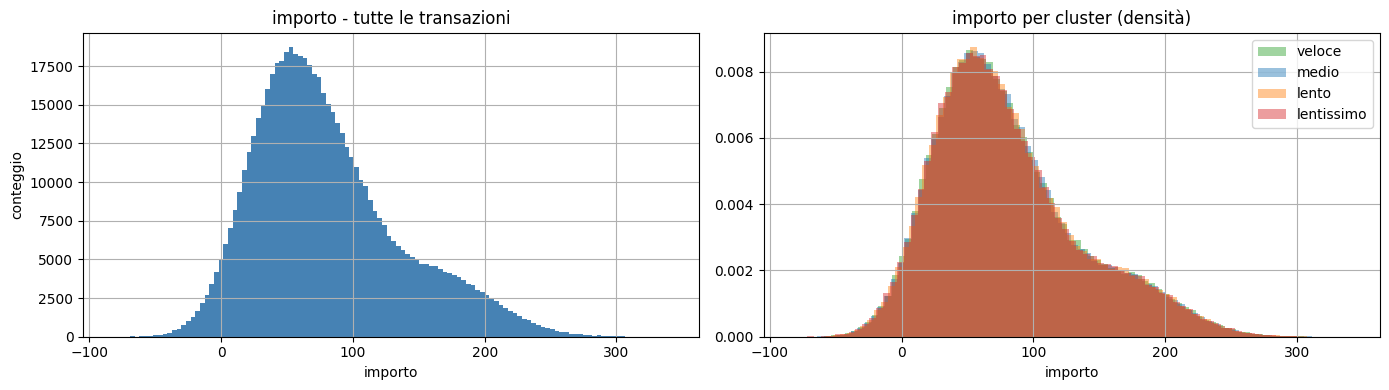

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].hist(df[AMOUNT], bins=120, color='steelblue')
ax[0].set(title='importo - tutte le transazioni', xlabel='importo', ylabel='conteggio')
for c in clusters:
    ax[1].hist(df.loc[df[CLUSTER] == c, AMOUNT], bins=80, alpha=0.45, density=True, label=c, color=colors_map[c])
ax[1].set(title='importo per cluster (densità)', xlabel='importo')
ax[1].legend()
plt.tight_layout()

df.groupby(CLUSTER)[AMOUNT].agg(['mean', 'median', 'std']).reindex(clusters).round(2)


## 3. Variabili categoriche: `merchant` e `cocau`

Anche le variabili categoriche sono condivise: il notebook serve a
verificare che non emerga un pattern di cluster “spaziale”.


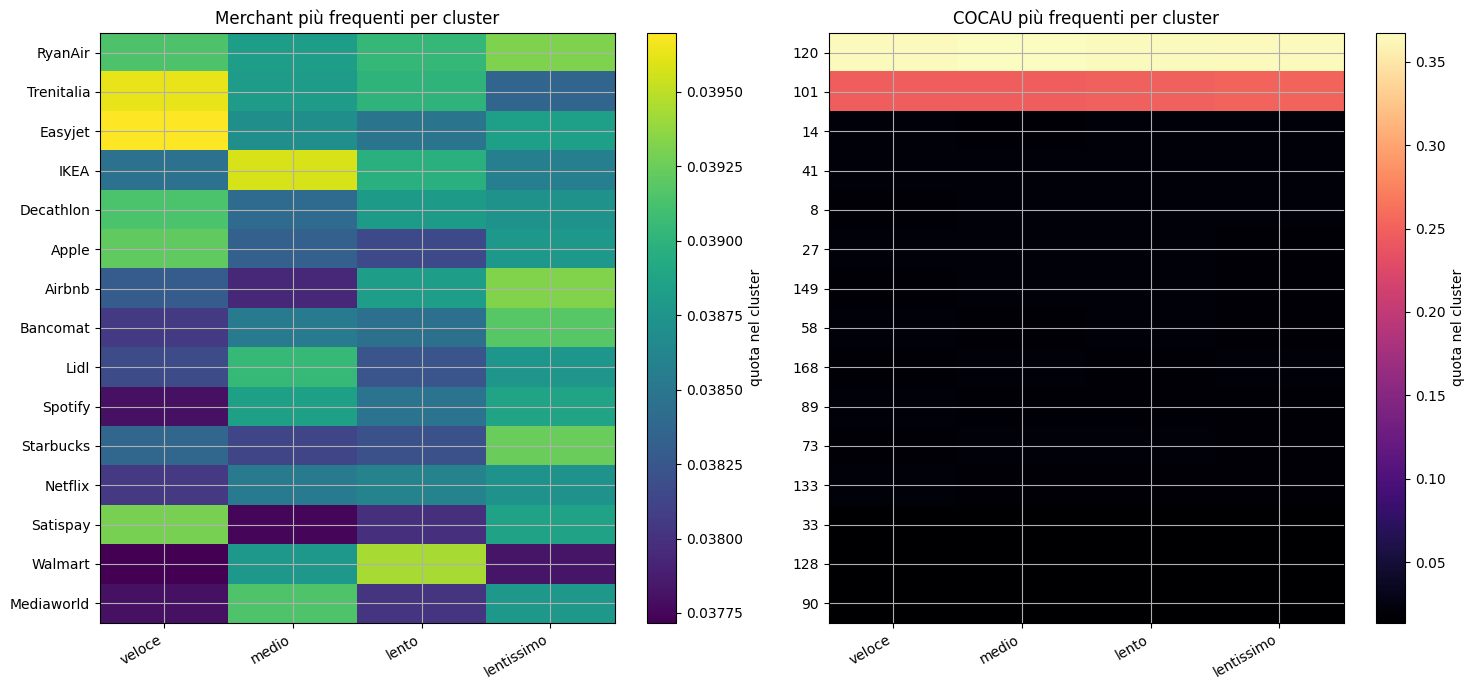

In [6]:
merchant_ct = pd.crosstab(df[MERCHANT], df[CLUSTER], normalize='columns')
top_merchants = df[MERCHANT].value_counts().head(15).index
merchant_ct = merchant_ct.reindex(index=top_merchants, columns=clusters)

cocau_top = df[COCAU].value_counts().head(15).index
cocau_ct = pd.crosstab(df[COCAU], df[CLUSTER], normalize='columns')
cocau_ct = cocau_ct.reindex(index=cocau_top, columns=clusters)

fig, ax = plt.subplots(1, 2, figsize=(15, 7))
im0 = ax[0].imshow(merchant_ct.values, aspect='auto', cmap='viridis')
ax[0].set_xticks(range(len(merchant_ct.columns)))
ax[0].set_xticklabels(merchant_ct.columns, rotation=30, ha='right')
ax[0].set_yticks(range(len(merchant_ct.index)))
ax[0].set_yticklabels(merchant_ct.index)
ax[0].set_title('Merchant più frequenti per cluster')
fig.colorbar(im0, ax=ax[0], label='quota nel cluster')

im1 = ax[1].imshow(cocau_ct.values, aspect='auto', cmap='magma')
ax[1].set_xticks(range(len(cocau_ct.columns)))
ax[1].set_xticklabels(cocau_ct.columns, rotation=30, ha='right')
ax[1].set_yticks(range(len(cocau_ct.index)))
ax[1].set_yticklabels(cocau_ct.index)
ax[1].set_title('COCAU più frequenti per cluster')
fig.colorbar(im1, ax=ax[1], label='quota nel cluster')

plt.tight_layout()


## 4. Variabili temporali

Qui è dove deve comparire il segnale. Ora del giorno e giorno della
settimana sono casuali; il discriminante è `delta_t`.


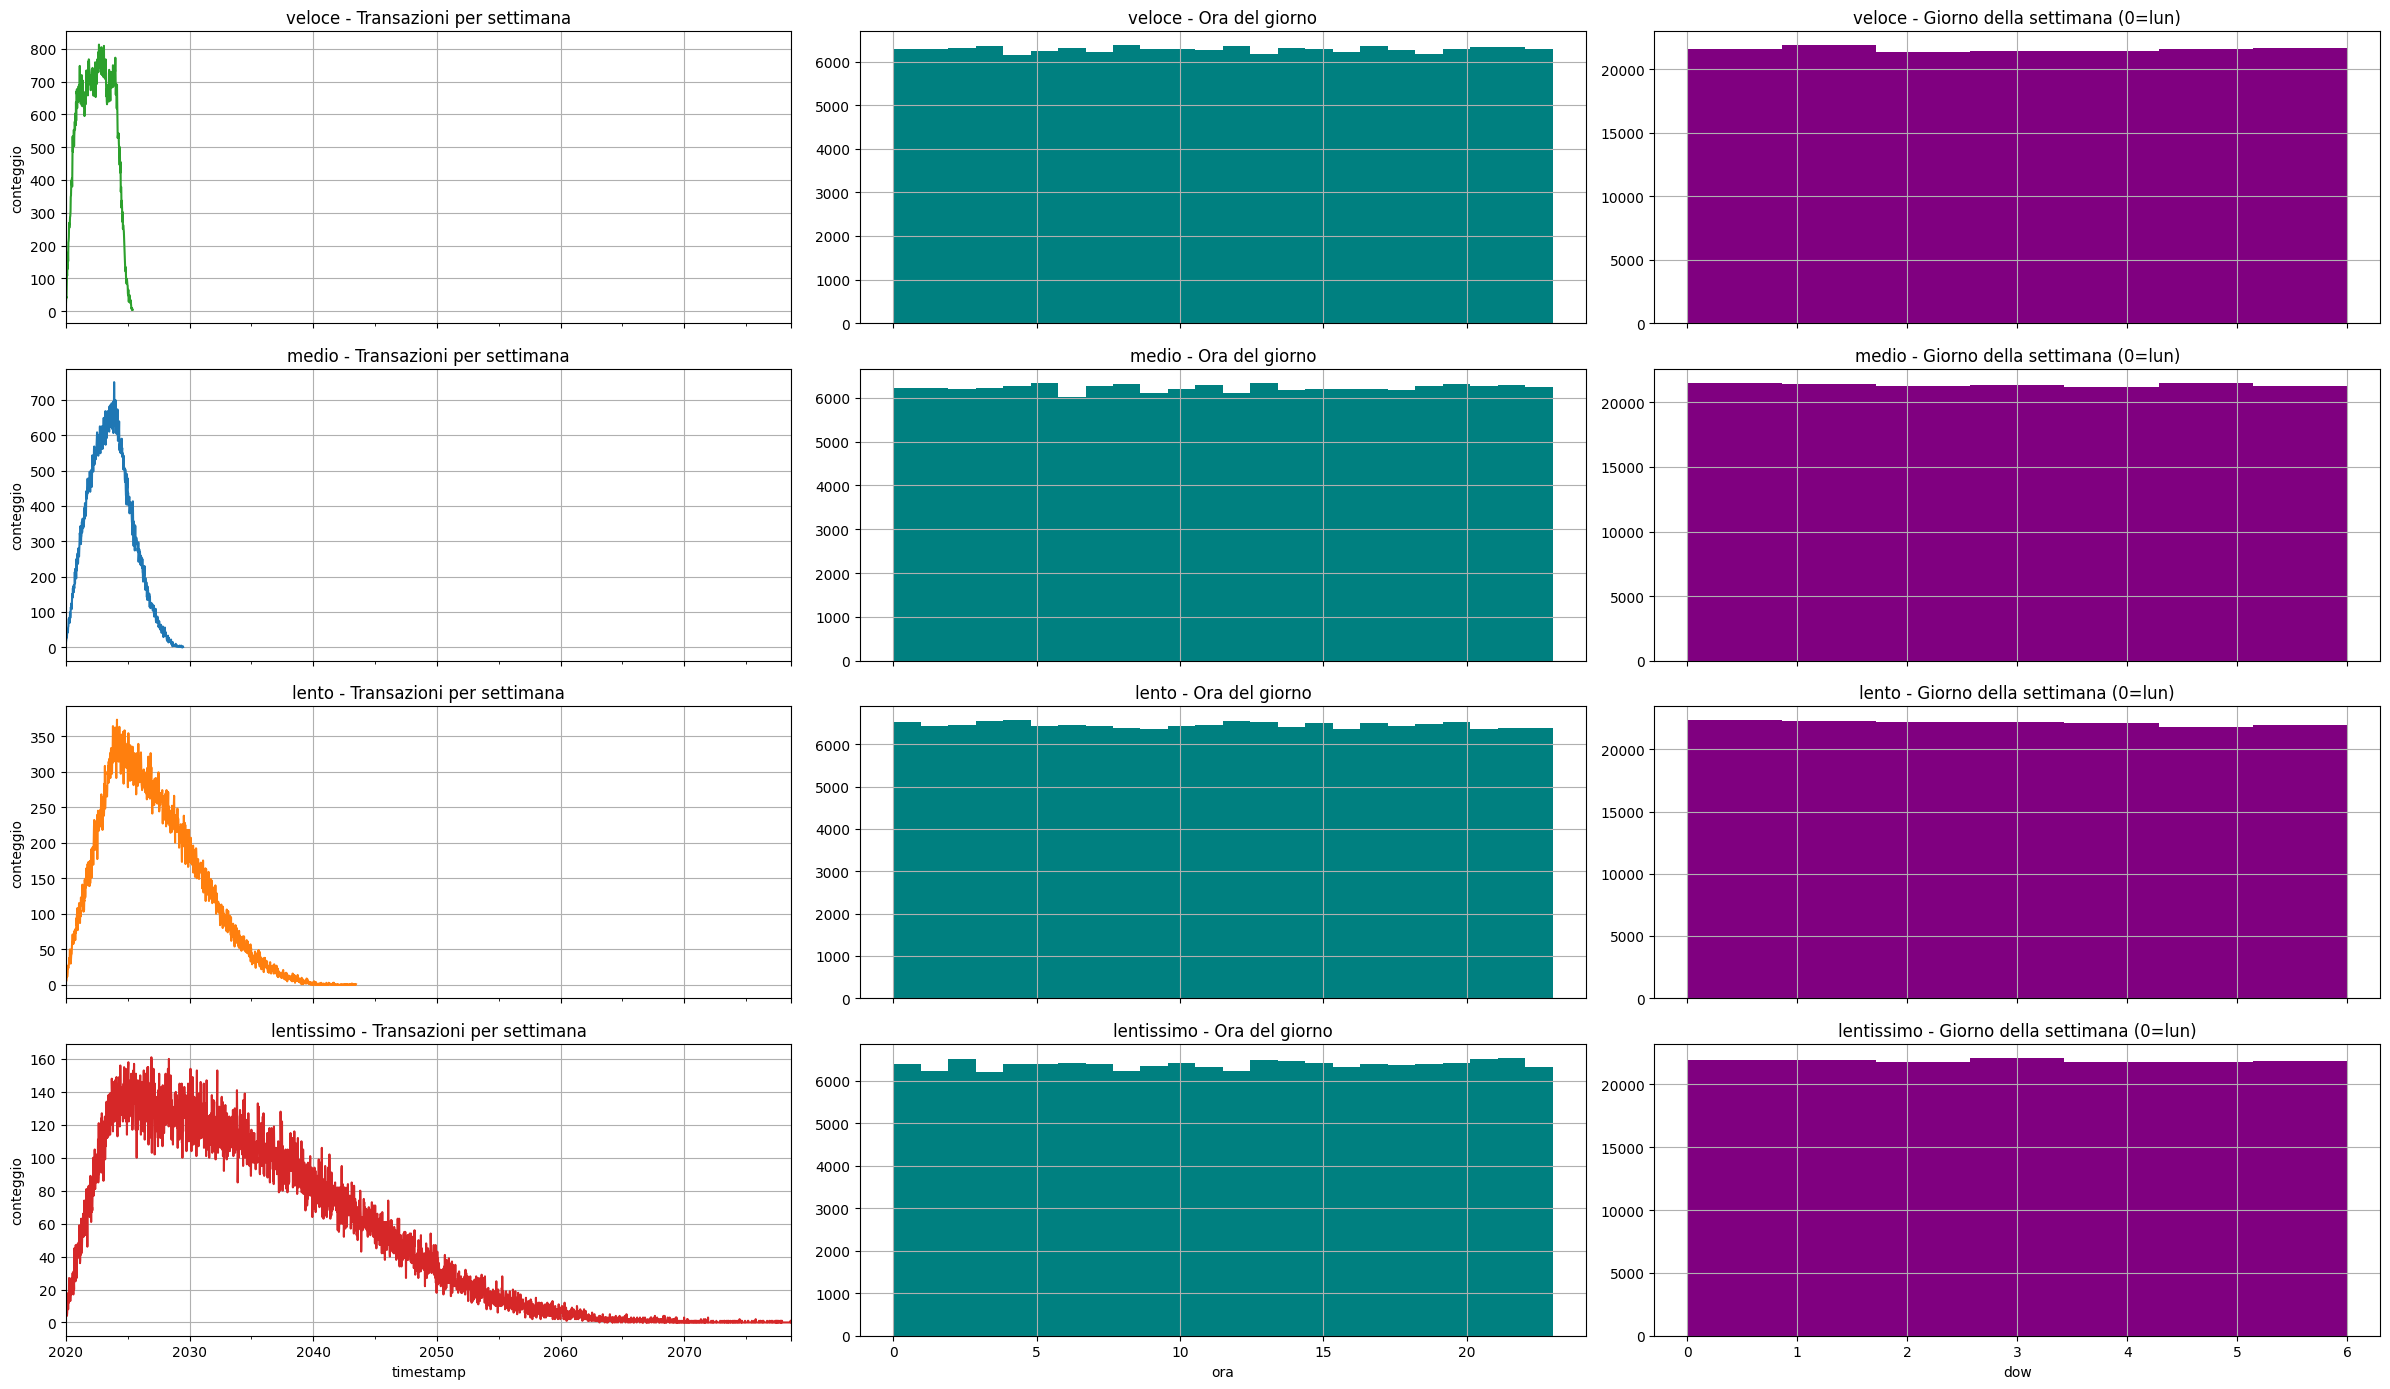

In [7]:
 fig, ax = plt.subplots(len(clusters), 3, figsize=(24, 3.5 * len(clusters)), sharex='col')
 
 for row, c in enumerate(clusters):
     df_c = df.loc[df[CLUSTER] == c].copy()
     weekly = df_c.set_index(TS).resample('W').size()
     weekly.plot(ax=ax[row, 0], color=colors_map[c])
     ax[row, 0].set_title(f'{c} - Transazioni per settimana')
     ax[row, 0].set_ylabel('conteggio')
 
     ax[row, 1].hist(df_c[TS].dt.hour, bins=24, color='teal')
     ax[row, 1].set_title(f'{c} - Ora del giorno')
 
     ax[row, 2].hist(df_c[TS].dt.dayofweek, bins=7, color='purple')
     ax[row, 2].set_title(f'{c} - Giorno della settimana (0=lun)')
 
 for row in range(len(clusters)):
     ax[row, 1].set_xlabel('ora')
     ax[row, 2].set_xlabel('dow')
 
 plt.tight_layout()


,mean,median,std,theoretical_mean_days
cluster,,,,
veloce,2.00,1.39,2.01,2.0
medio,6.98,4.84,6.99,7.0
lento,19.96,13.83,19.95,20.0
lentissimo,50.16,34.91,49.95,50.0


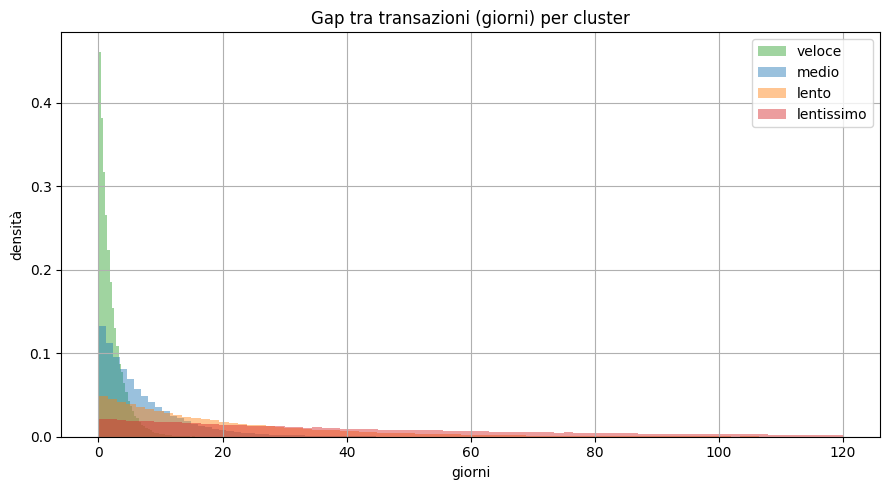

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
for c in clusters:
    gap = df.loc[df[CLUSTER] == c, 'delta_t_days'].dropna()
    ax.hist(gap[gap < 120], bins=80, alpha=0.45, density=True, label=c, color=colors_map[c])
ax.set(title='Gap tra transazioni (giorni) per cluster', xlabel='giorni', ylabel='densità')
ax.legend()
plt.tight_layout()

observed_gap = df.groupby(CLUSTER)['delta_t_days'].agg(['mean', 'median', 'std']).reindex(clusters)
observed_gap['theoretical_mean_days'] = pd.Series(theoretical_mean_gap_days)
observed_gap.round(2)


## 5. Transazioni per cliente

Anche il volume per cliente è condiviso a livello di generatore: ci
aspettiamo differenze contenute tra cluster.


,mean,median,std
cluster,,,
veloce,150.91,150.0,65.57
medio,149.52,149.0,67.75
lento,154.96,155.5,68.90
lentissimo,153.18,153.0,68.76


count    4000.000000
mean      152.142750
std        67.764677
min         1.000000
25%       105.000000
50%       152.000000
75%       198.000000
max       411.000000
dtype: float64

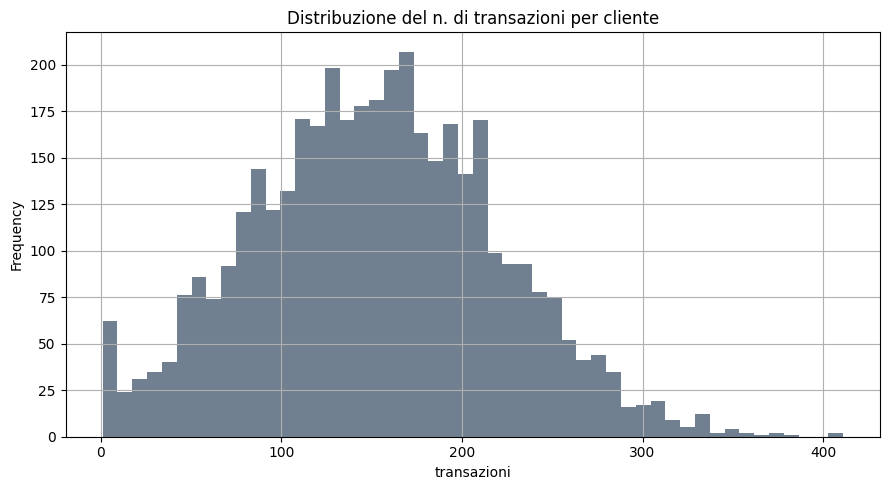

In [9]:
tx_per_client = df.groupby(CLIENT).size()
ax = tx_per_client.plot.hist(bins=50, title='Distribuzione del n. di transazioni per cliente', color='slategray')
ax.set_xlabel('transazioni')
plt.tight_layout()

tx_by_cluster = df.groupby([CLUSTER, CLIENT]).size().groupby(CLUSTER).agg(['mean', 'median', 'std']).reindex(clusters)
display(tx_by_cluster.round(2))
tx_per_client.describe()


## 6. Proiezione dei clienti (PCA & t-SNE)

I cluster sono definiti a livello di **cliente**, non di singola transazione.
Aggregando ogni cliente, ci aspettiamo che la separazione emerga soprattutto
dalle feature temporali (`gap_mean_days`, `gap_std_days`, quantili del gap),
non da `importo`, `merchant` o `cocau`.


Varianza spiegata cumulata: [0.1   0.197 0.268 0.318 0.361 0.394 0.423 0.451 0.479 0.506]


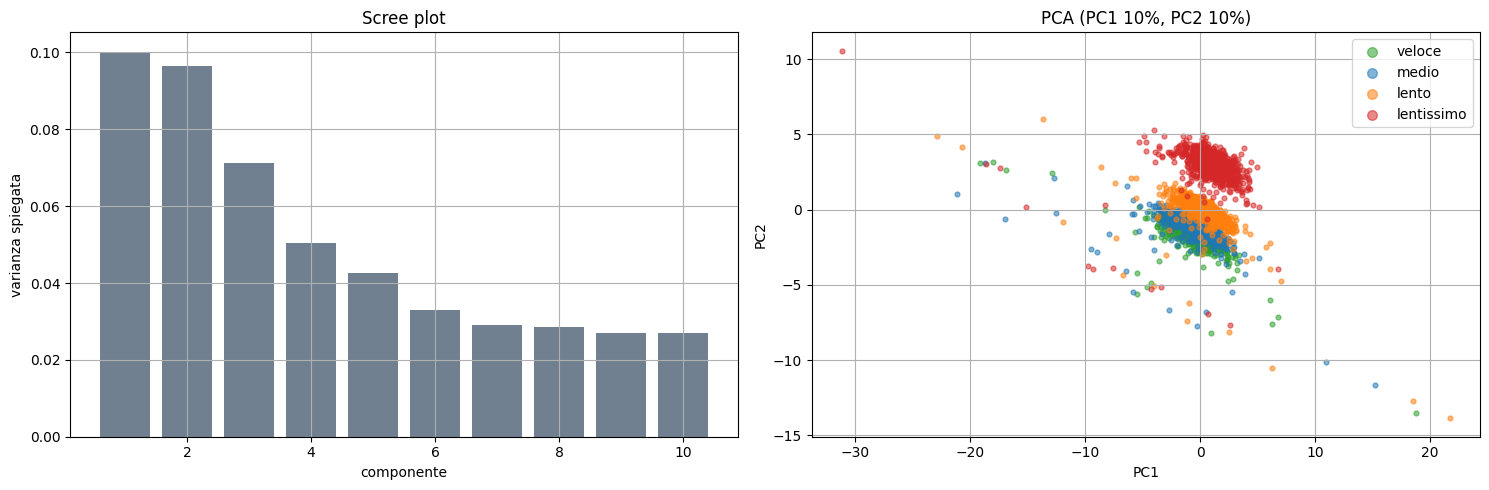

In [10]:
df_feat = df.assign(cocau_str=df[COCAU].astype(str))

base = df_feat.groupby(CLIENT).agg(
    amount_mean=(AMOUNT, 'mean'),
    amount_std=(AMOUNT, 'std'),
    amount_median=(AMOUNT, 'median'),
    amount_abs_mean=(AMOUNT, lambda s: s.abs().mean()),
    debt_share=(AMOUNT, lambda s: (s < 0).mean()),
    gap_mean_days=('delta_t_days', 'mean'),
    gap_median_days=('delta_t_days', 'median'),
    gap_std_days=('delta_t_days', 'std'),
    gap_p90_days=('delta_t_days', lambda s: s.quantile(0.9)),
    n_tx=(CLIENT, 'size'),
    n_merchant=(MERCHANT, 'nunique'),
    n_cocau=('cocau_str', 'nunique'),
)

merchant_share = pd.crosstab(df_feat[CLIENT], df_feat[MERCHANT], normalize='index')
merchant_share = merchant_share.reindex(columns=top_merchants, fill_value=0)
merchant_share.columns = [f'merchant__{c}' for c in merchant_share.columns]

top_cocau_str = df_feat['cocau_str'].value_counts().head(15).index
cocau_share = pd.crosstab(df_feat[CLIENT], df_feat['cocau_str'], normalize='index')
cocau_share = cocau_share.reindex(columns=top_cocau_str, fill_value=0)
cocau_share.columns = [f'cocau__{c}' for c in cocau_share.columns]

feats = base.join(merchant_share).join(cocau_share).fillna(0.0)
labels = df_feat.groupby(CLIENT)[CLUSTER].first().reindex(feats.index)

X = StandardScaler().fit_transform(feats.values)
pca = PCA(n_components=min(10, X.shape[1]), random_state=0).fit(X)
Xp = pca.transform(X)
evr = pca.explained_variance_ratio_
print('Varianza spiegata cumulata:', np.round(np.cumsum(evr), 3))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].bar(range(1, len(evr) + 1), evr, color='slategray')
ax[0].set(title='Scree plot', xlabel='componente', ylabel='varianza spiegata')

for c in clusters:
    m = labels.values == c
    ax[1].scatter(Xp[m, 0], Xp[m, 1], s=12, alpha=0.55, label=c, color=colors_map[c])
ax[1].set(title=f'PCA (PC1 {evr[0]:.0%}, PC2 {evr[1]:.0%})', xlabel='PC1', ylabel='PC2')
ax[1].legend(markerscale=2)
plt.tight_layout()


In [11]:
load = pd.DataFrame(pca.components_[:2].T, index=feats.columns, columns=['PC1', 'PC2'])
order = load['PC1'].abs().add(load['PC2'].abs()).sort_values(ascending=False).index
load.loc[order].head(15).round(3)


,PC1,PC2
gap_mean_days,0.162,0.447
gap_p90_days,0.162,0.447
gap_std_days,0.161,0.446
gap_median_days,0.159,0.441
amount_mean,0.429,-0.168
amount_abs_mean,0.428,-0.163
amount_median,0.373,-0.189
cocau__101,-0.257,0.159
amount_std,0.215,0.073
merchant__Starbucks,-0.177,0.081


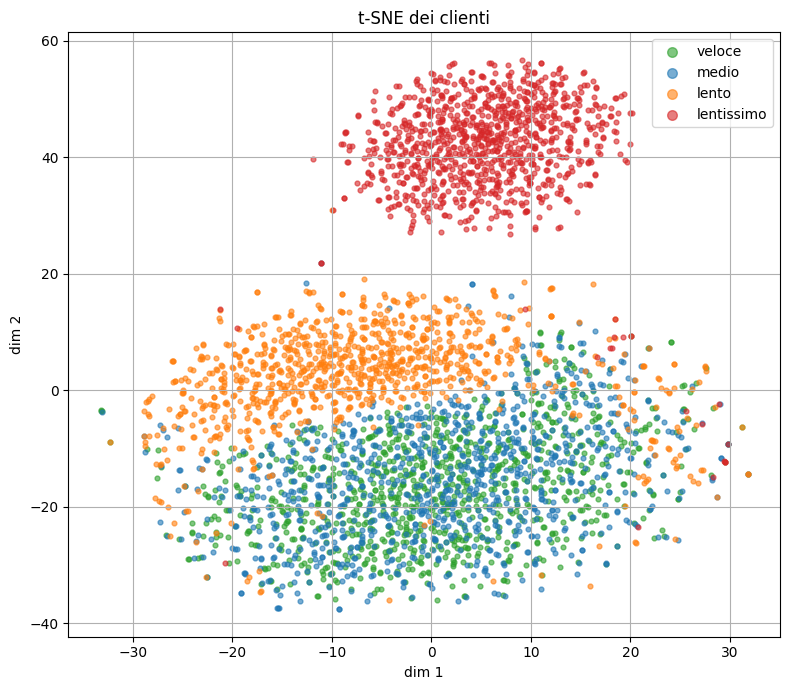

In [12]:
tsne = TSNE(n_components=2, perplexity=35, init='pca', learning_rate='auto', random_state=0)
Xt = tsne.fit_transform(X)

fig, ax = plt.subplots(figsize=(8, 7))
for c in clusters:
    m = labels.values == c
    ax.scatter(Xt[m, 0], Xt[m, 1], s=12, alpha=0.6, label=c, color=colors_map[c])
ax.set(title='t-SNE dei clienti', xlabel='dim 1', ylabel='dim 2')
ax.legend(markerscale=2)
plt.tight_layout()


## 7. Conclusioni

* `importo`, `merchant` e `cocau` risultano ampiamente sovrapposti tra i
  cluster: è coerente con il generatore, che usa un unico profilo condiviso.
* La separazione emerge sulle statistiche di **`delta_t`**: `veloce` ha gap
  medi più brevi, `lentissimo` più lunghi, con `medio` e `lento` nel mezzo.
* Nelle proiezioni PCA / t-SNE le feature temporali dovrebbero pesare più
  delle altre: se i cluster si separano, il modello sta leggendo davvero il
  canale del gap temporale.
